## Evaluation pipeline for the microlane experiment

In [1]:
# First consider all the variables
# The input image gets resized to a particular level
# Then create a pipeline to feed data into the model
# AFter this process is completed, then process the data
# Then after the processing is done find a way to take output from the model
# Then, convert the output to relevant format, and store it for future use
# Apply relevant computations

In [2]:
# Imports of the Core Packages
import json, sys, time
from pathlib import Path
from datetime import datetime

import cv2
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import yaml
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import random


In [3]:
# Import custom libraries located at different folder location + configs
from microlane.utils.metrics import *
from microlane.datasets.tusimple import TuSimple
from microlane.models.lanenet2.model import LaneNet2
from microlane.schema.output import LaneNet2Output

In [4]:
# First Load the Configuation file
with open("configs/config.yaml", "r") as file:
    config = yaml.safe_load(file)

### Pre Processing Part

In [5]:
# First initialise the dataset
# Then load the dataset
dataset = TuSimple(
        folder_path=config['data']['datasets']['tusimple']['path'],
        annotation_file_path=config['data']['datasets']['tusimple']['annotation_file']
    )

data = dataset.load(number=10)

data = dataset.load_images(data)

In [6]:
# Print some basic information of our data

print(f"Total items: {len(data)}\n")

random_image_index = random.randint(0, len(data)-1)

item = data[random_image_index]
print(f"Image Path   : {item.image_path}")
print(f"Lanes        : {item.actual_lanes}")
print(type(item.image))

Total items: 10

Image Path   : /home/suyog/assets/datasets/TuSimple/TUSimple/test_set/clips/0530/1492626617873533069_0/20.jpg
Lanes        : [LaneLine(x_coordinates=[-2, -2, -2, -2, -2, -2, -2, -2, -2, -2, 536, 505, 475, 444, 413, 383, 352, 321, 291, 260, 229, 198, 168, 137, 106, 76, 45, 14, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2], y_coordinates=[160, 170, 180, 190, 200, 210, 220, 230, 240, 250, 260, 270, 280, 290, 300, 310, 320, 330, 340, 350, 360, 370, 380, 390, 400, 410, 420, 430, 440, 450, 460, 470, 480, 490, 500, 510, 520, 530, 540, 550, 560, 570, 580, 590, 600, 610, 620, 630, 640, 650, 660, 670, 680, 690, 700, 710]), LaneLine(x_coordinates=[-2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2, 605, 594, 584, 573, 562, 552, 541, 531, 520, 510, 499, 489, 478, 467, 457, 446, 436, 425, 415, 404, 394, 383, 372, 362, 351, 341, 330, 320, 309, 298, 288, 277, 267, 256, 246, 235, 225, 214, 203, 193, 182, 172, 161, 151, 140], y_

(np.float64(-0.5), np.float64(1279.5), np.float64(719.5), np.float64(-0.5))

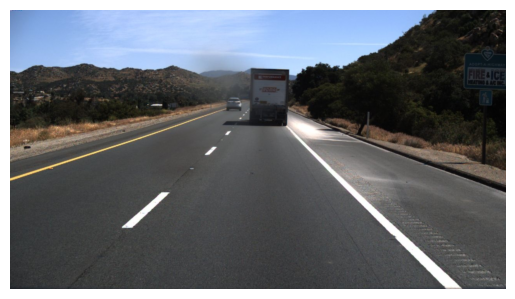

In [7]:
# Print Image as well
if item.image is None:
    raise ValueError("Image not found or failed to load")

plt.imshow(item.image)
plt.axis('off')  # hide axes


### Processing Part where we do the Inference

In [8]:
# So, basically now we will import the model
# model = LaneNet2() type and what we will do is, run 
# Run model.inference(formatted_dataset)

model = LaneNet2(
    container_folder=config['models']['lanenet2']['container_folder'],
    image_name=config['models']['lanenet2']['image_name']
)

Initializing container on port  8000
/home/suyog/desktop/projects/microlane/microlane/models/lanenet2/lanenet2
Building image 'lanenet2_image:latest' from [/home/suyog/desktop/projects/microlane/microlane/models/lanenet2/lanenet2/dockerfile] ...
Step 1/12 : FROM python:3.6.15-slim

---> 2cfebc27956e
Step 2/12 : LABEL maintainer="suyog224356@gmail.com"

---> Running in 1ebf33c353a5
---> Removed intermediate container 1ebf33c353a5
---> 20d97555a1b5
Step 3/12 : LABEL description="Docker container for lane detection using lanenet2"

---> Running in 8c4e83b54491
---> Removed intermediate container 8c4e83b54491
---> 2dbe335dbf2e
Step 4/12 : LABEL python_version="3.6.15"

---> Running in 33e8c48efd7e
---> Removed intermediate container 33e8c48efd7e
---> 046630cbf859
Step 5/12 : RUN apt-get update && apt-get install -y     git     build-essential     libgl1-mesa-glx     libglib2.0-0     libsm6     libxext6     libxrender-dev     && rm -rf /var/lib/apt/lists/*

---> Running in f21bb164b9c6
Get:

In [23]:
response = model.predict(item)

In [24]:
prediction = LaneNet2Output( **response.json() )

sample = prediction.sample
binary_seg = prediction.binary_segmentation

(np.float64(-0.5), np.float64(511.5), np.float64(255.5), np.float64(-0.5))

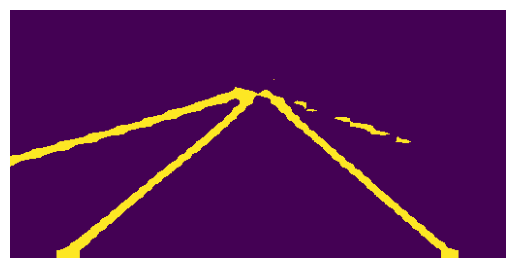

In [25]:

plt.imshow(binary_seg)
plt.axis('off')  # hide axes